# EDA ERA5 — Variables Meteorológicas Cali (2020-2025)
**Variables:** t2m, d2m, u10, v10, tp, sp, blh, stl1, ssr  
**Formato:** NetCDF4/HDF5 horario  
**Salida:** visualizaciones in-line + PNGs en `outputs/eda/era5/`


## 1. Imports y configuración

In [1]:
import json, glob, warnings
from pathlib import Path
import numpy as np
import h5py
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings("ignore")

ROOT = Path().resolve().parent.parent   # ajusta según tu estructura
DATA_DIR = ROOT / "data" / "era5"
OUT_DIR  = ROOT / "outputs" / "eda" / "era5"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DPI = 150

VARS = {
    "t2m":  "2m Temperature [K]",
    "d2m":  "2m Dewpoint [K]",
    "u10":  "U-wind [m/s]",
    "v10":  "V-wind [m/s]",
    "tp":   "Total Precip [m]",
    "sp":   "Surface Pressure [Pa]",
    "blh":  "Boundary Layer Height [m]",
    "stl1": "Soil Temp [K]",
    "ssr":  "Solar Radiation [J/m²]",
}
VAR_KEYS = {"ssr": "ssrd"}
UNITS = {"t2m": "°C", "tp": "mm", "ssr": "W/m²"}

def save(name):
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    p = OUT_DIR / f"{name}.png"
    plt.savefig(p, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()
    return p

print("Configuración lista ✅")


Configuración lista ✅


## 2. Carga de datos

In [2]:
def read_file(path, var_short):
    """Lee un NetCDF ERA5 y extrae serie temporal media espacial."""
    try:
        with h5py.File(path, "r") as f:
            vn = VAR_KEYS.get(var_short, var_short)
            if vn not in f:
                return None, None
            data = f[vn][:]          # (time, lat, lon) o (1, time, lat, lon)
            time_key = "valid_time" if "valid_time" in f else "time"
            time_data = f[time_key][:]
            while data.ndim > 2 and data.shape[0] == 1:
                data = data[0]
            mean_ts = np.nanmean(data, axis=(1,)) if data.ndim == 2 else data.flatten()
            return mean_ts, time_data
    except Exception:
        return None, None

print("Cargando ERA5 (hasta 648 archivos)...")
files = sorted(DATA_DIR.rglob("*.nc"))
print(f"  → {len(files)} archivos encontrados")

ts_data = {v: {"time": [], "values": []} for v in VARS}

for f in files:
    parts = f.stem.split("_")
    if len(parts) < 5:
        continue
    var = parts[4] if parts[4] in VARS else parts[-1]
    if var not in VARS:
        for i in [4, 5, 6]:
            if i < len(parts) and parts[i] in VARS:
                var = parts[i]
                break
        else:
            continue
    mean_ts, time_ts = read_file(f, var)
    if mean_ts is not None and len(mean_ts) > 0 and time_ts is not None:
        l = min(len(mean_ts.flatten()), len(time_ts.flatten()))
        ts_data[var]["time"].extend(time_ts.flatten()[:l].tolist())
        ts_data[var]["values"].extend(mean_ts.flatten()[:l].tolist())

print("Carga completada ✅")


Cargando ERA5 (hasta 648 archivos)...
  → 648 archivos encontrados
Carga completada ✅


## 3. Construcción y conversión de unidades

In [3]:
dfs = {}
for var in VARS:
    if ts_data[var]["values"]:
        df = pd.DataFrame({
            "time": pd.to_datetime(ts_data[var]["time"], unit="s", origin="unix"),
            "value": ts_data[var]["values"],
        }).sort_values("time").drop_duplicates("time")
        val = df["value"].values
        if var in ("t2m", "d2m", "stl1"):
            val = val - 273.15
        elif var == "tp":
            val = val * 1000
        elif var in ("ssr", "ssrd"):
            val = val / 3600
        elif var == "sp":
            val = val / 100
        df["value"] = val
        dfs[var] = df

print(f"Variables cargadas: {len(dfs)}")
for v, df in sorted(dfs.items()):
    print(f"  {v}: {len(df):,} puntos  |  {df['time'].min().date()} → {df['time'].max().date()}")


Variables cargadas: 9
  blh: 52,608 puntos  |  2020-01-01 → 2025-12-31
  d2m: 52,608 puntos  |  2020-01-01 → 2025-12-31
  sp: 52,608 puntos  |  2020-01-01 → 2025-12-31
  ssr: 52,608 puntos  |  2020-01-01 → 2025-12-31
  stl1: 52,608 puntos  |  2020-01-01 → 2025-12-31
  t2m: 52,608 puntos  |  2020-01-01 → 2025-12-31
  tp: 52,608 puntos  |  2020-01-01 → 2025-12-31
  u10: 52,608 puntos  |  2020-01-01 → 2025-12-31
  v10: 52,608 puntos  |  2020-01-01 → 2025-12-31


## Fig 1 — Temperatura 2m: serie temporal

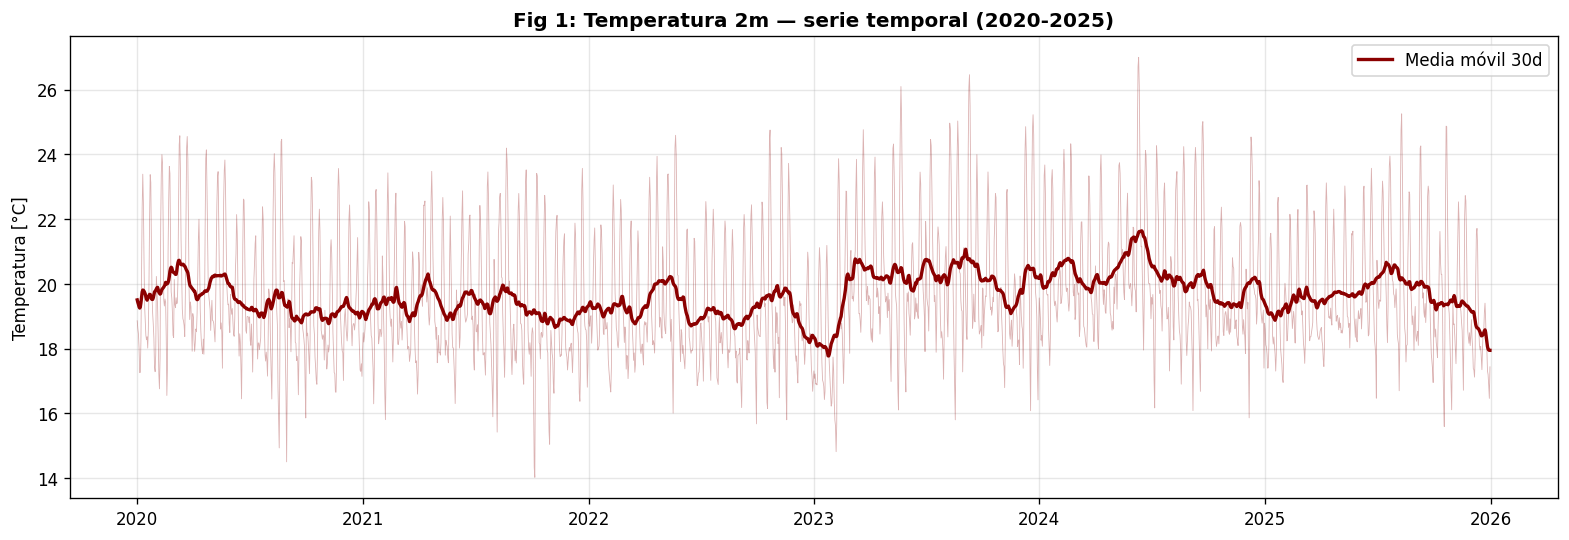

In [4]:
if "t2m" in dfs:
    d    = dfs["t2m"].set_index("time").resample("D").mean().dropna()
    roll = d["value"].rolling(30, center=True, min_periods=5).mean()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(d.index, d["value"], alpha=0.3, lw=0.5, color="darkred")
    ax.plot(d.index, roll, lw=2, color="darkred", label="Media móvil 30d")
    ax.set_ylabel("Temperatura [°C]")
    ax.legend()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_title("Fig 1: Temperatura 2m — serie temporal (2020-2025)", fontweight="bold")
    ax.grid(alpha=0.3)
    save("01_temperatura_serie")


## Fig 2 — Precipitación total mensual

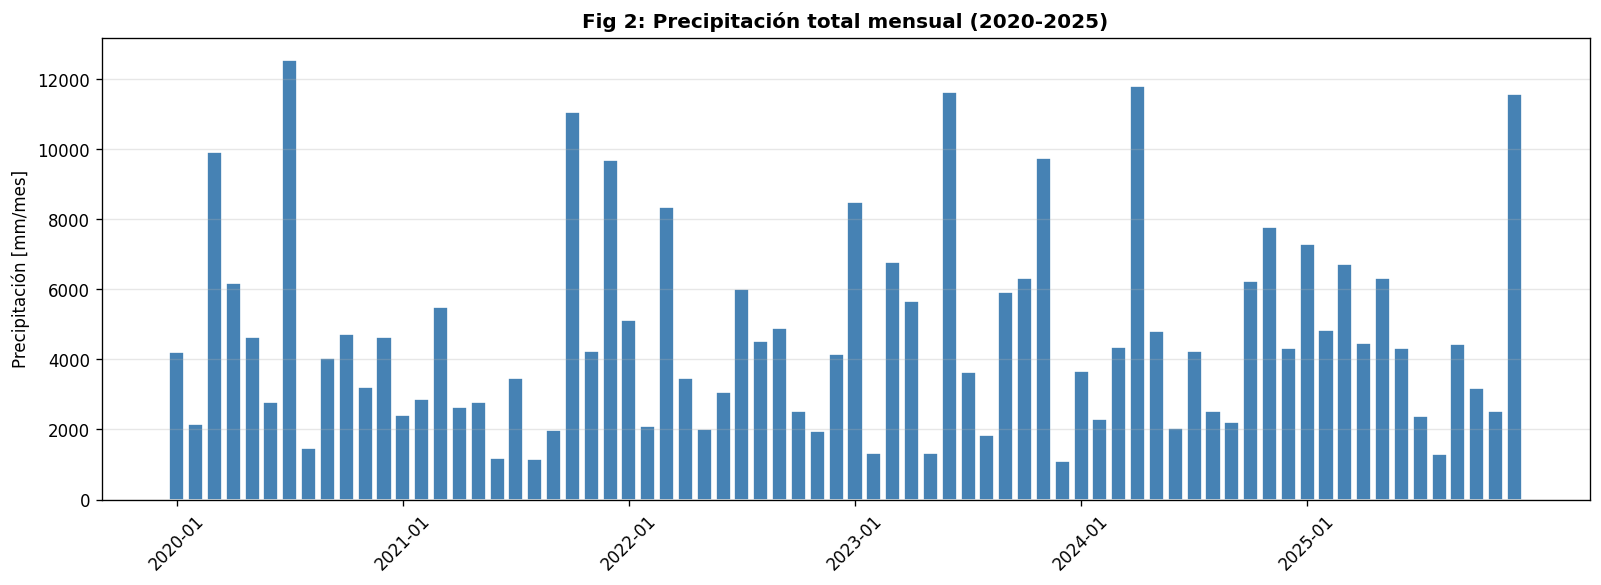

In [5]:
if "tp" in dfs:
    d = dfs["tp"].copy()
    d["mes"] = d["time"].dt.to_period("M")
    monthly = d.groupby("mes")["value"].sum()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(range(len(monthly)), monthly.values, color="steelblue", edgecolor="white")
    ax.set_xticks(range(0, len(monthly), 12))
    ax.set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), 12)], rotation=45)
    ax.set_ylabel("Precipitación [mm/mes]")
    ax.set_title("Fig 2: Precipitación total mensual (2020-2025)", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    save("02_precipitacion_mensual")


## Fig 3 — Ciclo anual de temperatura (boxplots)

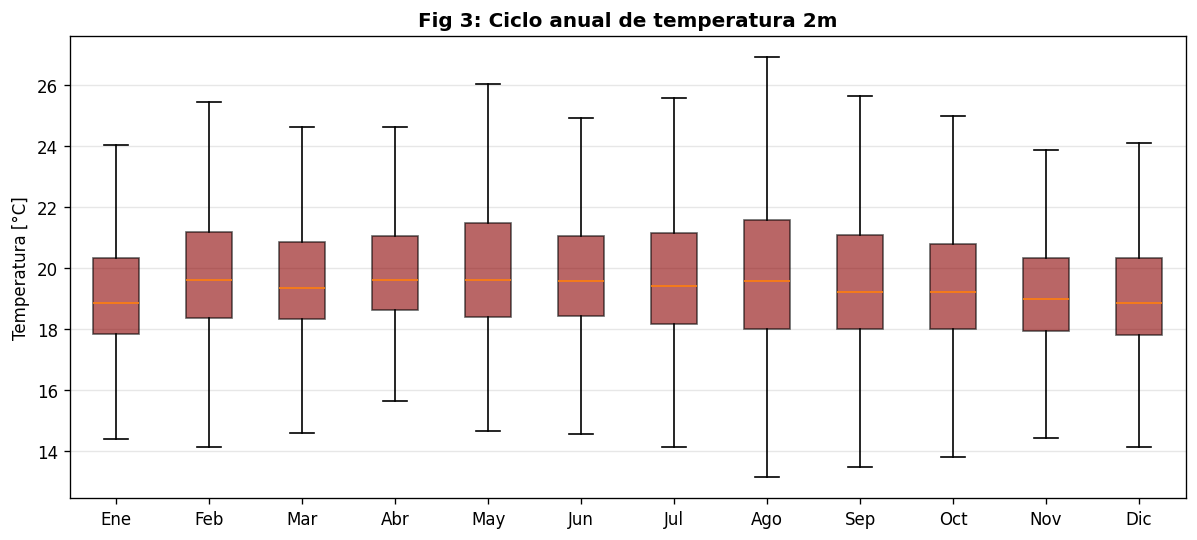

In [6]:
if "t2m" in dfs:
    d = dfs["t2m"].copy()
    d["mes"] = d["time"].dt.month
    data = [d[d["mes"] == m]["value"].dropna().values for m in range(1, 13)]

    fig, ax = plt.subplots(figsize=(12, 5))
    bp = ax.boxplot(data, patch_artist=True, showfliers=False)
    for p in bp["boxes"]:
        p.set_facecolor("darkred")
        p.set_alpha(0.6)
    ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
    ax.set_ylabel("Temperatura [°C]")
    ax.grid(axis="y", alpha=0.3)
    ax.set_title("Fig 3: Ciclo anual de temperatura 2m", fontweight="bold")
    save("03_temperatura_ciclo_anual")


## Fig 4 — Ciclo diurno de temperatura

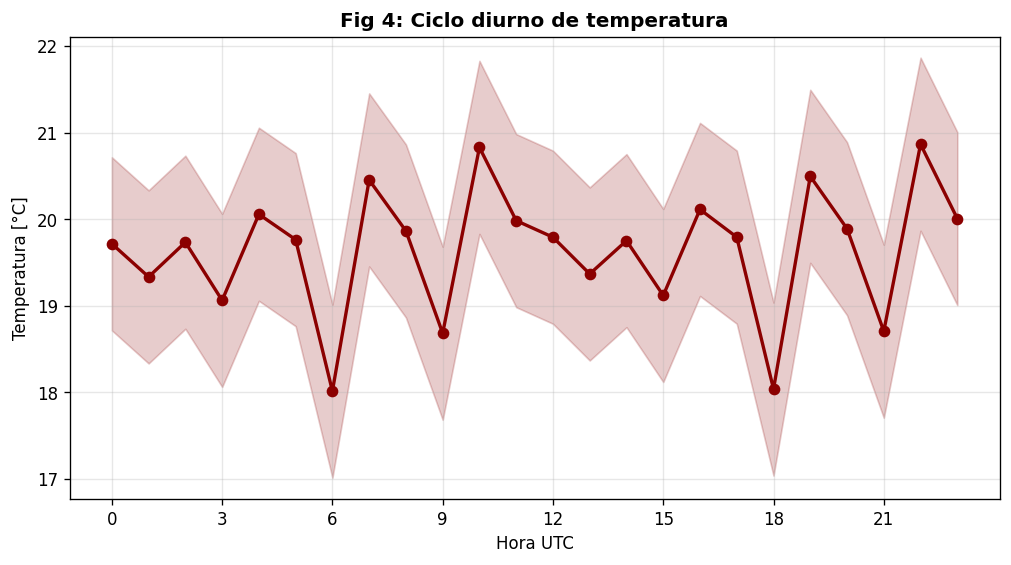

In [7]:
if "t2m" in dfs:
    d = dfs["t2m"].copy()
    d["hora"] = d["time"].dt.hour
    hourly = d.groupby("hora")["value"].mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(hourly.index, hourly.values - 1, hourly.values + 1,
                    alpha=0.2, color="darkred")
    ax.plot(hourly.index, hourly.values, "o-", lw=2, color="darkred")
    ax.set_xlabel("Hora UTC")
    ax.set_ylabel("Temperatura [°C]")
    ax.set_xticks(range(0, 24, 3))
    ax.set_title("Fig 4: Ciclo diurno de temperatura", fontweight="bold")
    ax.grid(alpha=0.3)
    save("04_temperatura_ciclo_diurno")


## Fig 5 — Rosa de vientos

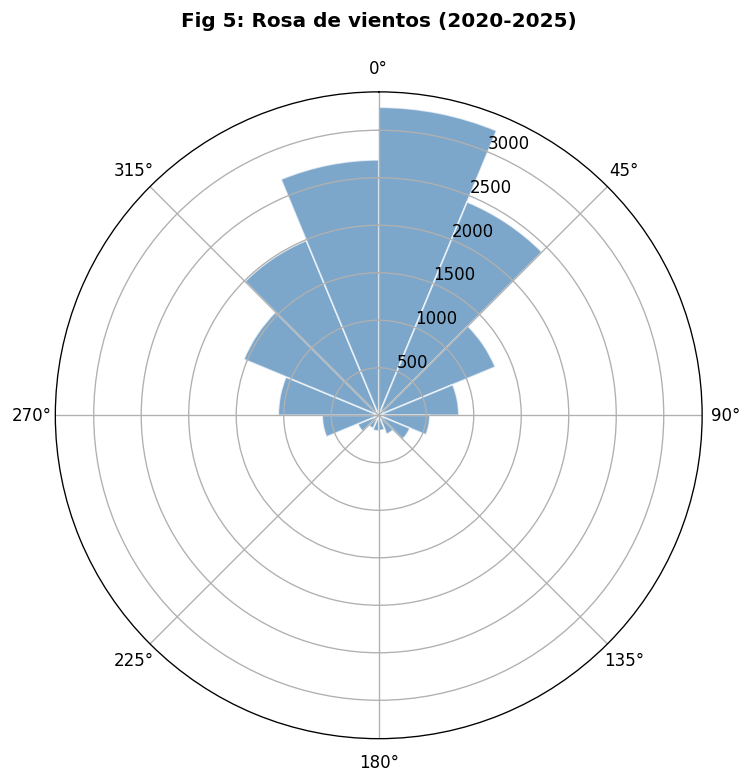

In [8]:
if "u10" in dfs and "v10" in dfs:
    d_u = dfs["u10"].set_index("time").resample("3h").mean().dropna()
    d_v = dfs["v10"].set_index("time").resample("3h").mean().dropna()
    common = d_u.index.intersection(d_v.index)
    wspd = np.sqrt(d_u.loc[common]["value"] ** 2 + d_v.loc[common]["value"] ** 2)
    wdir = np.arctan2(d_u.loc[common]["value"], d_v.loc[common]["value"]) * 180 / np.pi + 180

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
    bins = np.linspace(0, 2 * np.pi, 17)
    ax.hist(np.deg2rad(wdir), bins=bins, color="steelblue", alpha=0.7, edgecolor="white")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title("Fig 5: Rosa de vientos (2020-2025)", fontweight="bold", pad=20)
    save("05_rosa_vientos")


## Fig 6 — Altura de capa límite (BLH)

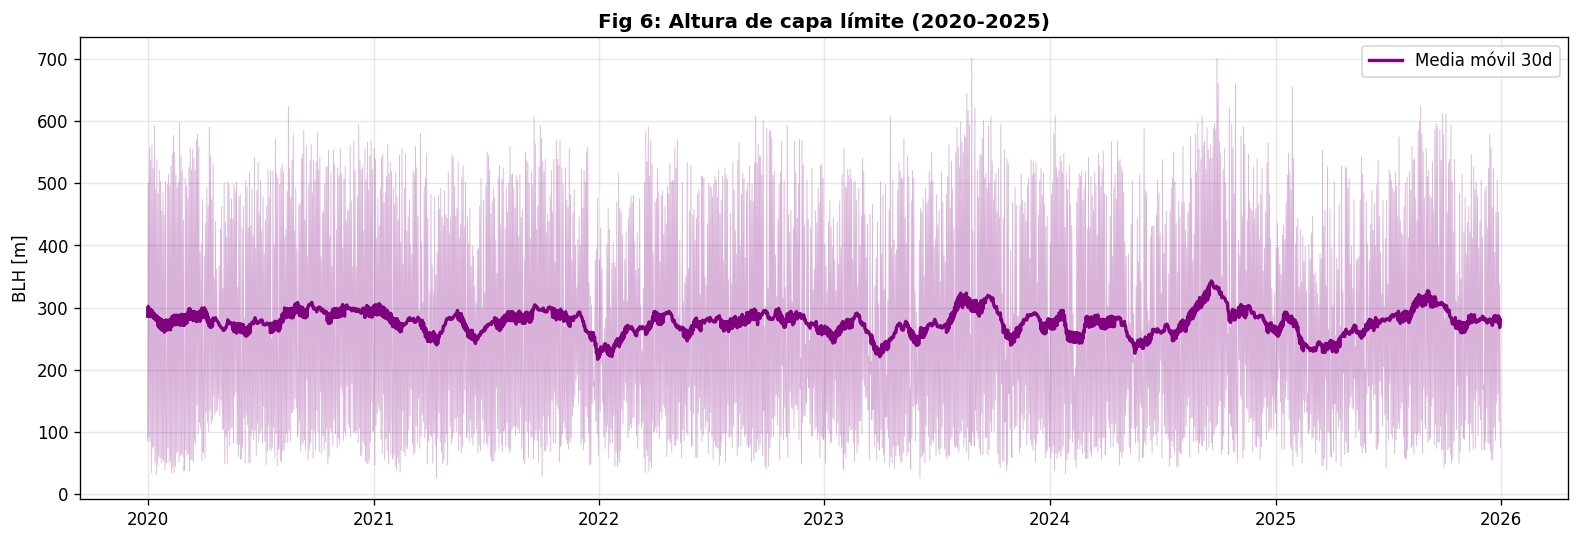

In [9]:
if "blh" in dfs:
    d    = dfs["blh"].set_index("time").resample("D").mean().dropna()
    roll = d["value"].rolling(30, center=True, min_periods=5).mean()

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(d.index, d["value"], alpha=0.3, lw=0.5, color="purple")
    ax.plot(d.index, roll, lw=2, color="purple", label="Media móvil 30d")
    ax.set_ylabel("BLH [m]")
    ax.legend()
    ax.set_title("Fig 6: Altura de capa límite (2020-2025)", fontweight="bold")
    ax.grid(alpha=0.3)
    save("06_blh_serie")


## Fig 7 — Radiación solar: ciclo anual

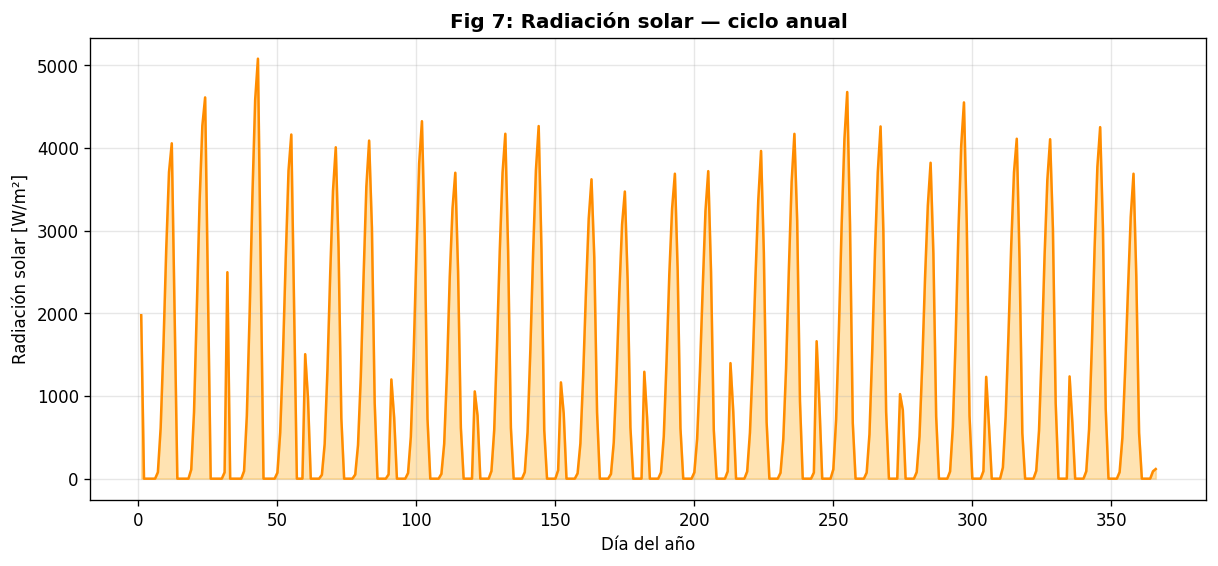

In [10]:
if "ssr" in dfs:
    d     = dfs["ssr"].set_index("time").resample("D").mean().dropna()
    daily = d.groupby(d.index.dayofyear)["value"].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(daily.index, daily.values, alpha=0.3, color="orange")
    ax.plot(daily.index, daily.values, lw=1.5, color="darkorange")
    ax.set_xlabel("Día del año")
    ax.set_ylabel("Radiación solar [W/m²]")
    ax.set_title("Fig 7: Radiación solar — ciclo anual", fontweight="bold")
    ax.grid(alpha=0.3)
    save("07_radiacion_solar")


## Fig 8 — Panorama multivariable

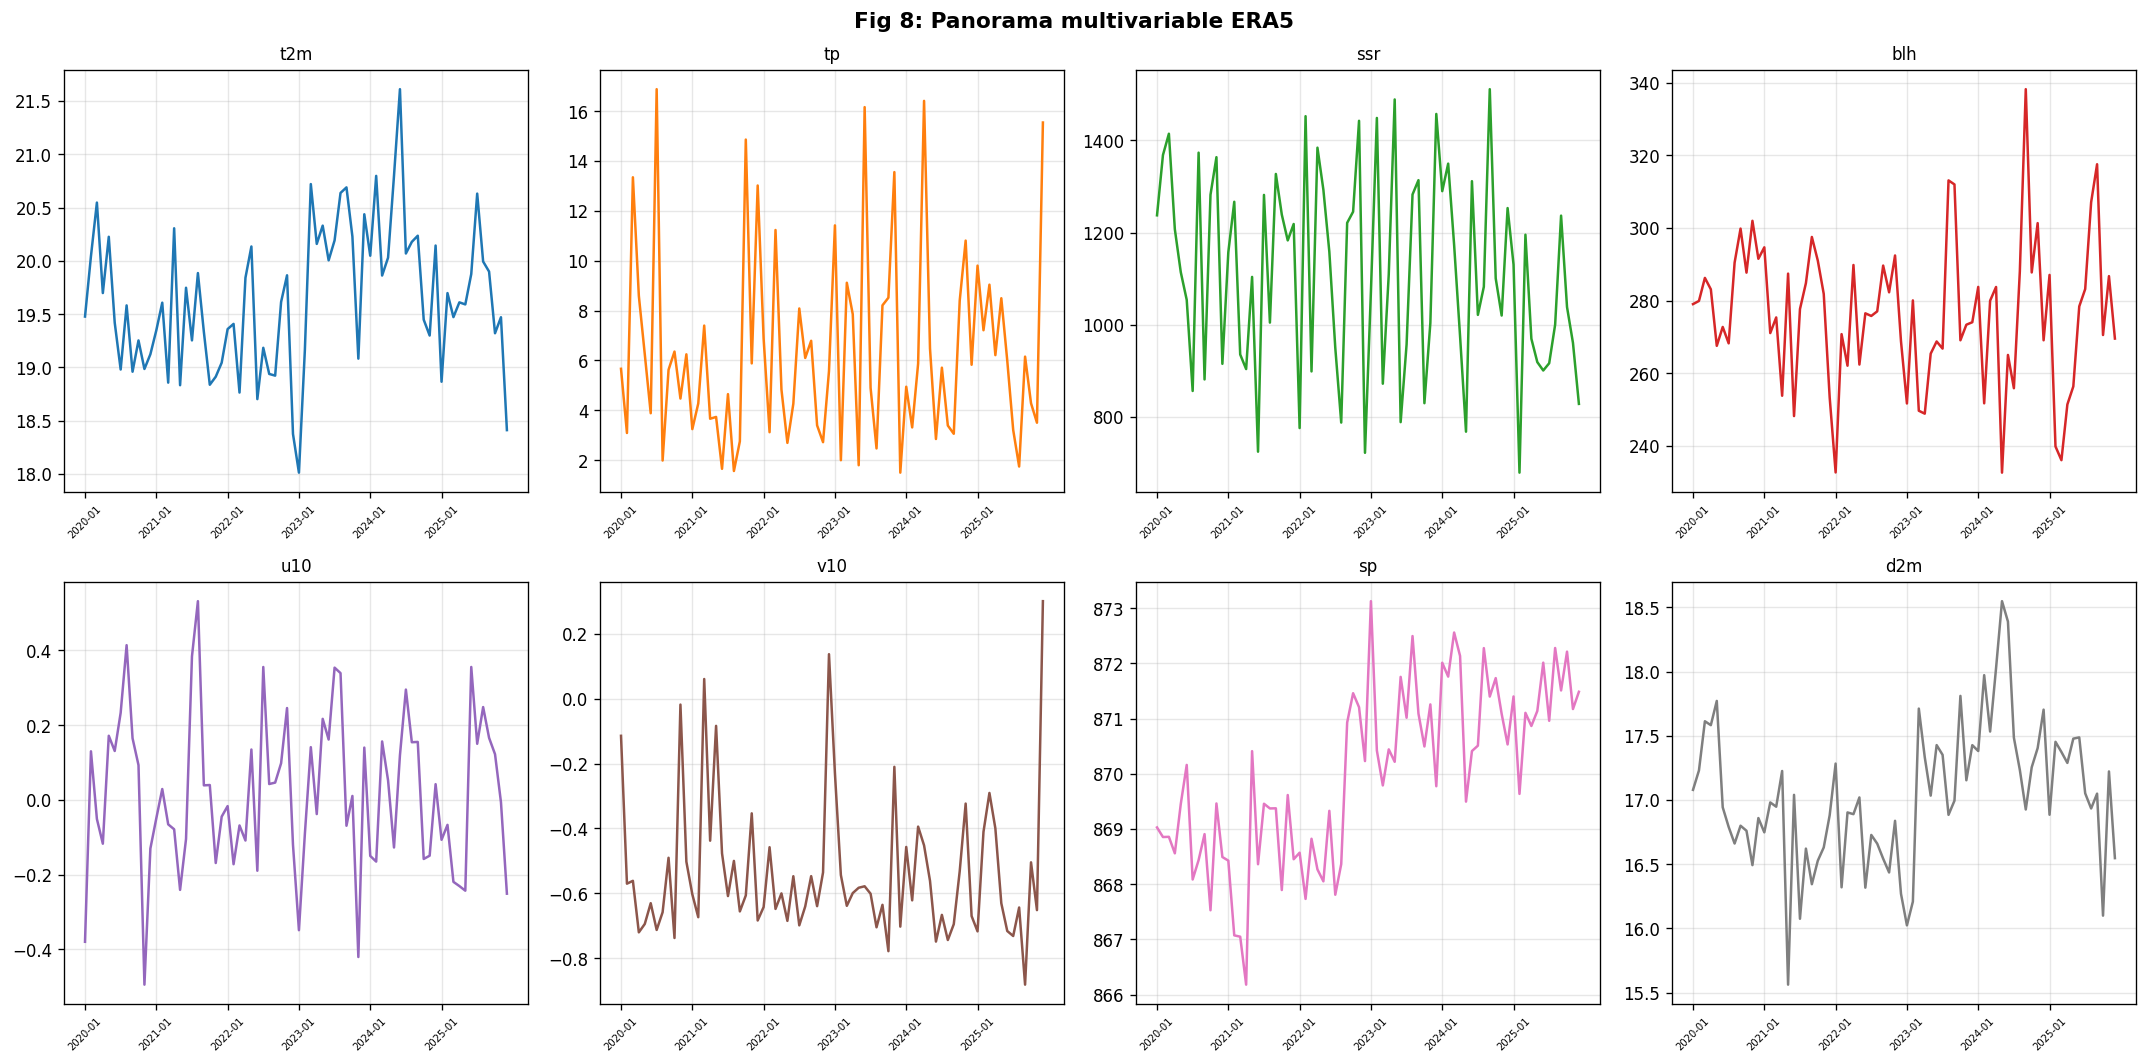

In [11]:
if len(dfs) >= 5:
    plot_vars = ["t2m", "tp", "ssr", "blh", "u10", "v10", "sp", "d2m"]
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    for ax, var in zip(axes.flat, plot_vars):
        if var in dfs:
            d = dfs[var].copy()
            d["mes"] = d["time"].dt.to_period("M")
            m = d.groupby("mes")["value"].mean()
            ax.plot(range(len(m)), m.values, lw=1.5,
                    color=plt.cm.tab10(plot_vars.index(var)))
            ax.set_title(var, fontsize=10)
            ax.set_xticks(range(0, len(m), 12))
            ax.set_xticklabels([str(m.index[i]) for i in range(0, len(m), 12)],
                               rotation=45, fontsize=6)
            ax.grid(alpha=0.3)

    fig.suptitle("Fig 8: Panorama multivariable ERA5", fontweight="bold", fontsize=13)
    fig.tight_layout()
    save("08_panorama_multivariable")


## Fig 9 — Temperatura vs Precipitación mensual

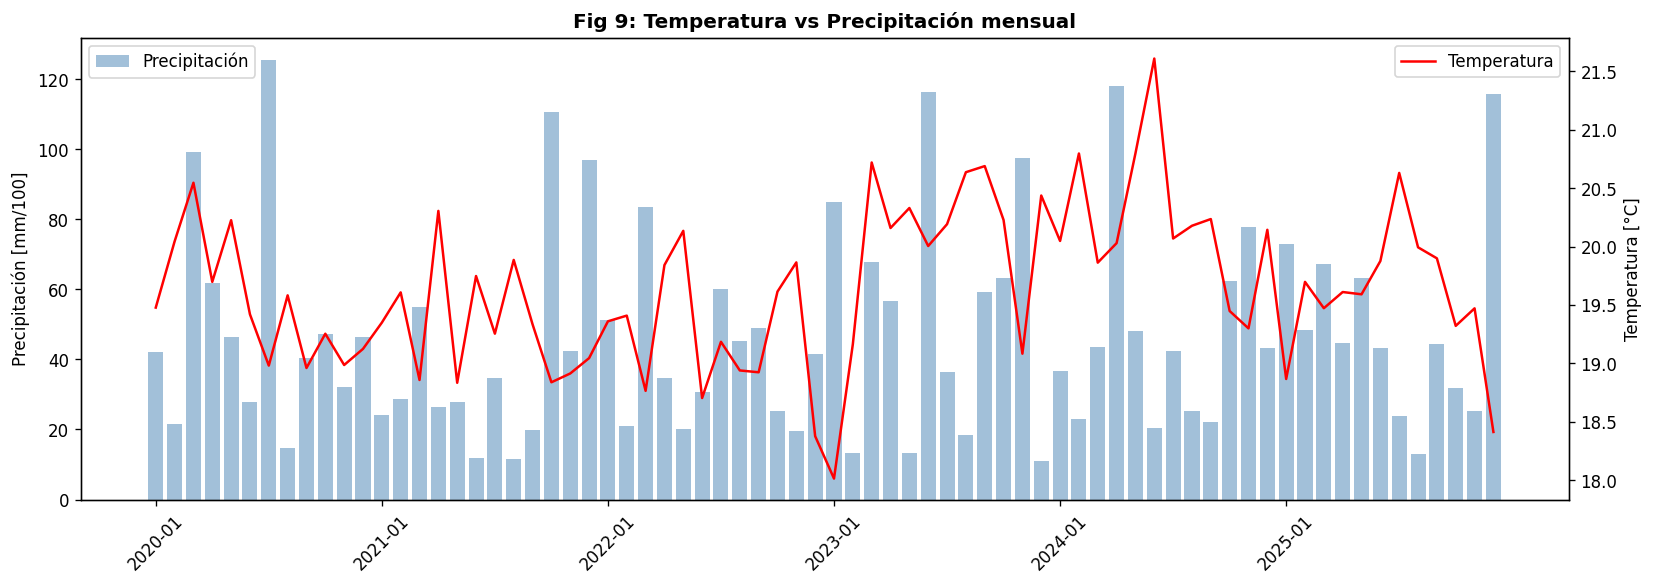

In [12]:
if "t2m" in dfs and "tp" in dfs:
    d_t = dfs["t2m"].set_index("time").resample("ME").mean()
    d_p = dfs["tp"].copy()
    d_p["mes"] = d_p["time"].dt.to_period("M")
    d_p = d_p.groupby("mes")["value"].sum()

    fig, ax1 = plt.subplots(figsize=(16, 5))
    ax1.bar(range(len(d_p)), d_p.values / 100, color="steelblue", alpha=0.5, label="Precipitación")
    ax1.set_ylabel("Precipitación [mm/100]")
    ax1.legend(loc="upper left")
    ax1.set_xticks(range(0, len(d_p), 12))
    ax1.set_xticklabels([str(d_p.index[i]) for i in range(0, len(d_p), 12)], rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(range(len(d_t)), d_t["value"], "r-", lw=1.5, label="Temperatura")
    ax2.set_ylabel("Temperatura [°C]")
    ax2.legend(loc="upper right")

    ax1.set_title("Fig 9: Temperatura vs Precipitación mensual", fontweight="bold")
    save("09_temp_vs_precip")


## Fig 10 — Matriz de correlación

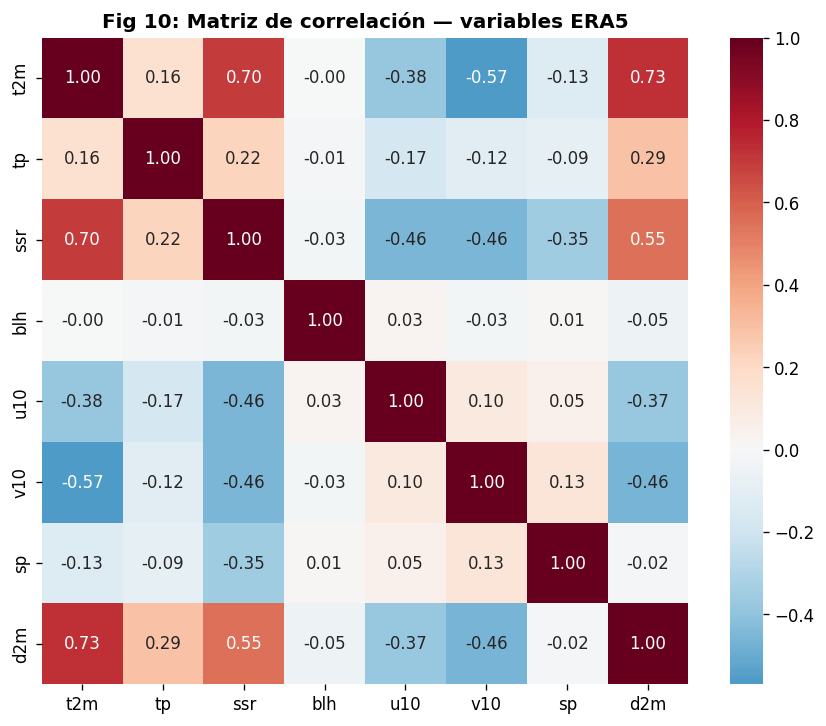

In [13]:
corr_vars = {}
for v in ["t2m", "tp", "ssr", "blh", "u10", "v10", "sp", "d2m"]:
    if v in dfs:
        corr_vars[v] = dfs[v].set_index("time")["value"].resample("D").mean().dropna()

if len(corr_vars) >= 4:
    corr_df = pd.DataFrame(corr_vars).corr()
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, square=True, ax=ax)
    ax.set_title("Fig 10: Matriz de correlación — variables ERA5", fontweight="bold")
    save("10_correlacion_era5")


## Fig 11 — Temperatura: ciclo diurno × mes

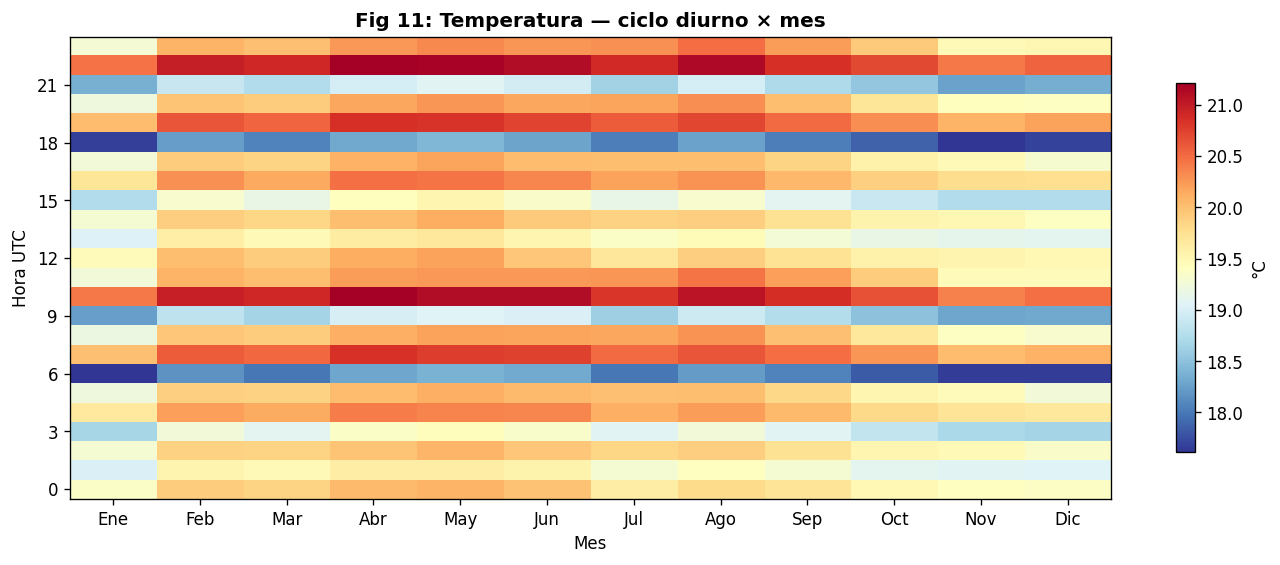

In [14]:
if "t2m" in dfs:
    d = dfs["t2m"].copy()
    d["hora"] = d["time"].dt.hour
    d["mes"]  = d["time"].dt.month
    pivot = d.groupby(["mes", "hora"])["value"].mean().unstack()

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(pivot.T, aspect="auto", cmap="RdYlBu_r", origin="lower")
    ax.set_xticks(range(12))
    ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
    ax.set_yticks(range(0, 24, 3))
    ax.set_yticklabels(range(0, 24, 3))
    ax.set_xlabel("Mes")
    ax.set_ylabel("Hora UTC")
    plt.colorbar(im, ax=ax, label="°C", shrink=0.8)
    ax.set_title("Fig 11: Temperatura — ciclo diurno × mes", fontweight="bold")
    save("11_temp_diurno_mes")


## Fig 12 — Tendencia anual de temperatura

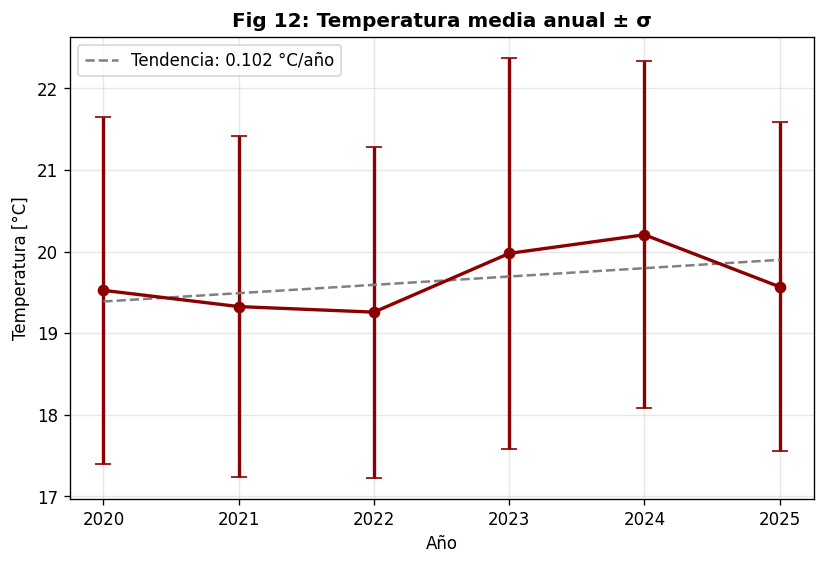

In [15]:
if "t2m" in dfs:
    d = dfs["t2m"].copy()
    d["ano"] = d["time"].dt.year
    annual = d.groupby("ano")["value"].agg(["mean", "std"])

    z = np.polyfit(annual.index, annual["mean"], 1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(annual.index, annual["mean"], yerr=annual["std"],
                fmt="o-", lw=2, color="darkred", capsize=5)
    ax.plot(annual.index, np.poly1d(z)(annual.index), "--", color="gray",
            label=f"Tendencia: {z[0]:.3f} °C/año")
    ax.set_xlabel("Año")
    ax.set_ylabel("Temperatura [°C]")
    ax.set_title("Fig 12: Temperatura media anual ± σ", fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    save("12_tendencia_temperatura")


## Resumen

In [16]:
pngs = list(OUT_DIR.glob("*.png"))
print(f"✅ EDA ERA5 completo")
print(f"   Directorio de salida : {OUT_DIR}")
print(f"   Gráficas generadas   : {len(pngs)}")
for p in sorted(pngs):
    print(f"   · {p.name}")


✅ EDA ERA5 completo
   Directorio de salida : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/era5
   Gráficas generadas   : 12
   · 01_temperatura_serie.png
   · 02_precipitacion_mensual.png
   · 03_temperatura_ciclo_anual.png
   · 04_temperatura_ciclo_diurno.png
   · 05_rosa_vientos.png
   · 06_blh_serie.png
   · 07_radiacion_solar.png
   · 08_panorama_multivariable.png
   · 09_temp_vs_precip.png
   · 10_correlacion_era5.png
   · 11_temp_diurno_mes.png
   · 12_tendencia_temperatura.png
